In [1]:
import numpy as np
import os
import seaborn as sb
import globals as gl
import PcmPy as pcm
from pcm_models import find_model
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from sklearn.preprocessing import MinMaxScaler
import nibabel as nb
import nitools as nt

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [2]:
experiment = 'smp2'
glm = 12
H = 'L'
rois = gl.rois['ROI']

SMA: tval=3.7412524069250153, pval=0.0012341176507395986
PMd: tval=4.632755946072445, pval=0.00023447725643595637
PMv: tval=4.871751027995077, pval=0.000152536469488637
M1: tval=4.855534566185381, pval=0.00015701575367410683
S1: tval=4.095856035259803, pval=0.0006314556974653611
SPLa: tval=4.6441182080136745, pval=0.000229695588941363
SPLp: tval=5.413064990715796, pval=5.923155085749077e-05


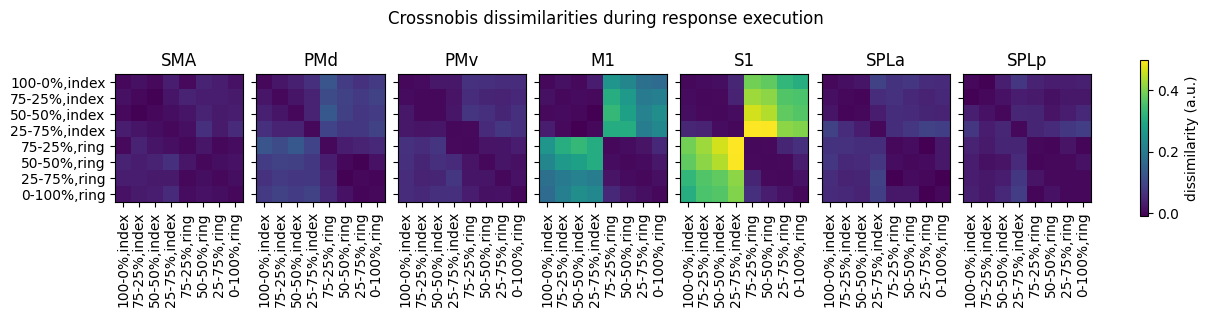

In [3]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .5

fig, axs = plt.subplots(1, len(rois), figsize=(12, 3),sharex=True, sharey=True, constrained_layout=True)
tr_null_plan, tr_pot_plan = [], []
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    tr_null_plan.append(np.trace(G, axis1=1, axis2=2))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[5:], vmin=vmin, vmax=vmax, sqrt=False, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response execution')

plt.show()


SMA:
sensory input, sign test (greater), pval=0.9935302734375
expectation, sign test (greater), pval=1.0
surprise, sign test (greater), pval=0.00091552734375

PMd:
sensory input, sign test (greater), pval=0.0064697265625
expectation, sign test (greater), pval=0.99908447265625
surprise, sign test (greater), pval=6.103515625e-05

PMv:
sensory input, sign test (greater), pval=0.78802490234375
expectation, sign test (greater), pval=1.0
surprise, sign test (greater), pval=6.103515625e-05

M1:
sensory input, sign test (greater), pval=6.103515625e-05
expectation, sign test (greater), pval=0.9713134765625
surprise, sign test (greater), pval=0.00091552734375

S1:
sensory input, sign test (greater), pval=0.000244140625
expectation, sign test (greater), pval=0.21197509765625
surprise, sign test (greater), pval=6.103515625e-05

SPLa:
sensory input, sign test (greater), pval=0.604736328125
expectation, sign test (greater), pval=0.99993896484375
surprise, sign test (greater), pval=6.103515625e-05



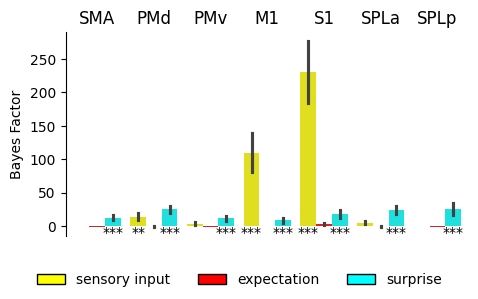

In [6]:
from vis import plot_comp_bayes, add_sig_var_expl, add_sig_1samp

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.p'), 'component')
n_param_c = Mc.n_param
components = ['sensory input', 'expectation', 'surprise']
palette = ['#FFFF00', 'red', 'cyan']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(5, 3), sharey=True, )
for r, roi in enumerate(rois):
    print(f'\n{roi}:')
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.exec.glm{glm}.{H}.{roi}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood, method='AIC', format='DataFrame')
    fig, axs = add_sig_1samp(fig, axs, r, c_bf, type='sign')
    fig, axs = plot_comp_bayes(fig, axs, r, c_bf, components=components, palette=palette)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.subplots_adjust(bottom=.2)
#axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-2])
plt.show()


SMA:
sesnory input, tval(greater)=-0.43747454514851114, pval=0.665526418371494
expectation, tval(greater)=-383292.10089654505, pval=1.0
surprise, tval(greater)=3.4817310889981177, pval=0.0020268098898016786
sesnory input vs. expectation, tval=2.1838215607418787, pval=0.047898546577406616
sesnory input vs. surprise, tval=-4.81563595696175, pval=0.000337257838855183
expectation vs. surprise, tval=-7.711702682119376, pval=3.3342843119881075e-06

PMd:
sesnory input, tval(greater)=2.8119221539028767, pval=0.007345279674786808
expectation, tval(greater)=-4.487225434430878, pval=0.9996942876672196
surprise, tval(greater)=4.8169560287028474, pval=0.00016823073515978375
sesnory input vs. expectation, tval=4.126819743947998, pval=0.0011917728816585528
sesnory input vs. surprise, tval=-1.56478758010842, pval=0.1416413500151412
expectation vs. surprise, tval=-7.075389324454138, pval=8.349866512444565e-06

PMv:
sesnory input, tval(greater)=1.3462708358496096, pval=0.10061068829296722
expectation, 

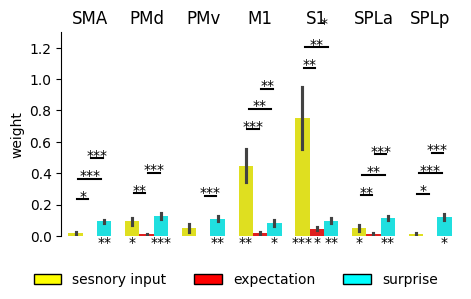

In [5]:
from vis import plot_var_expl, add_sig_var_expl

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.p'), 'component')
n_param_c = Mc.n_param
components = ['sesnory input', 'expectation', 'surprise']
palette = ['#FFFF00', 'red', 'cyan']
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components,)
fig, axs = plt.subplots(1, len(rois), figsize=(5, 3), sharey=True, )
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    fig, axs = plot_var_expl(fig, axs, r, param_c, components=components, palette=palette)
axs[0].set_ylim([0, 1.3])
for r, roi in enumerate(rois):
    print(f'\n{roi}:')
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.exec.glm{glm}.{H}.{roi}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood, method='AIC', format='DataFrame')
    fig, axs = add_sig_1samp(fig, axs, r, c_bf, type='ttest')
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.subplots_adjust(bottom=.2)

#axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-2])
plt.show()